# Week-09 Traffic Signal Control using Reinforcement Learning

## Problem Description

This assignment focuses on optimizing traffic signal control at an isolated four-leg intersection using Reinforcement Learning (RL).

The intersection consists of four approaches:

North (N)
South (S)
East (E)
West (W)


The traffic demand is stochastic, with vehicles arriving randomly at each approach.
The objective is to minimize congestion by reducing the total queue length across all directions.

Action 0 → North-South green

Action 1 → East-West green

Reward: r=-(qN + qS + qE + qW)

## System Modeling

### Reinforcement Learning Framework

The traffic signal control problem is modeled as a Reinforcement Learning (RL) problem consisting of the following components:

- **Agent:** Traffic signal controller  
- **Environment:** Traffic flow at the intersection  
- **State:** Current queue lengths at all approaches  
- **Action:** Selection of signal phase  
- **Reward:** Negative of total queue length  

The agent interacts with the environment and learns an optimal policy to minimize congestion over time.



### State Representation

The state is defined as:

\[
s = (q_N, q_S, q_E, q_W)
\]

where:
- \(q_N\): Queue length in North direction  
- \(q_S\): Queue length in South direction  
- \(q_E\): Queue length in East direction  
- \(q_W\): Queue length in West direction  

To simplify the problem, queue lengths are discretized into three levels:

- **0 (Low):** 0–4 vehicles  
- **1 (Medium):** 5–9 vehicles  
- **2 (High):** ≥10 vehicles  

This discretization reduces the size of the state space and improves learning efficiency.



### Action Space

The agent can take one of the following actions:

- **Action 0:** North–South green signal  
- **Action 1:** East–West green signal  

At any given time, only one direction is allowed to move.



### Reward Function

The reward is defined as:

\[
r = -(q_N + q_S + q_E + q_W)
\]

This formulation penalizes higher queue lengths and encourages the agent to minimize congestion.



### State Transition

At each time step, the system evolves as follows:

1. Vehicles arrive randomly at each direction  
2. The agent selects an action (signal phase)  
3. Vehicles are discharged in the green direction  
4. Updated queue lengths form the next state  



### Objective

The objective of the RL agent is to learn a policy \(\pi(s)\) that selects actions to maximize cumulative reward over time.

Maximizing reward corresponds to minimizing total queue length and improving traffic flow efficiency.

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import random

## Parameter Initialization

In [47]:
alpha = 0.1      # learning rate
gamma = 0.9      # discount factor
epsilon = 0.1    # exploration rate

episodes = 500
steps_per_episode = 100

## State Representation

Queues are discretized into:

Low (0–4)

Medium (5–9)

High (≥10)

In [48]:
def discretize(q):
    if q <= 4:
        return 0  # Low
    elif q <= 9:
        return 1  # Medium
    else:
        return 2  # High

def get_state(q):
    return tuple(discretize(x) for x in q)

## Q-Table Initialization

In [49]:
Q = {}

def get_Q(state):
    if state not in Q:
        Q[state] = [0, 0]  # [NS, EW]
    return Q[state]

## Traffic Simulation Model

Random arrivals + signal-based discharge.

In [50]:
def step_env(q, action):
    # Random arrivals (Poisson)
    arrivals = np.random.poisson(2, 4)
    q = q + arrivals

    # Discharge
    if action == 0:  # NS green
        q[0] = max(0, q[0] - 3)
        q[1] = max(0, q[1] - 3)
    else:  # EW green
        q[2] = max(0, q[2] - 3)
        q[3] = max(0, q[3] - 3)

    # Reward
    reward = -np.sum(q)

    return q, reward

## Traffic Simulation (Task 1)

### Objective

The purpose of this step is to simulate realistic traffic conditions at the intersection by generating random vehicle arrivals and observing how queues evolve over time.

This provides the environment on which the RL agent will later operate.

### Methodology

Vehicle arrivals are modeled using a Poisson distribution, which is commonly used for traffic flow.

Each direction (N, S, E, W) receives independent arrivals.

The cumulative number of vehicles is tracked to visualize traffic growth trends.

In [51]:
q = np.array([0, 0, 0, 0])
history = []

for _ in range(episodes):
    arrivals = np.random.poisson(2, 4)
    q += arrivals
    history.append(q.copy())

history = np.array(history)



### Visualisation


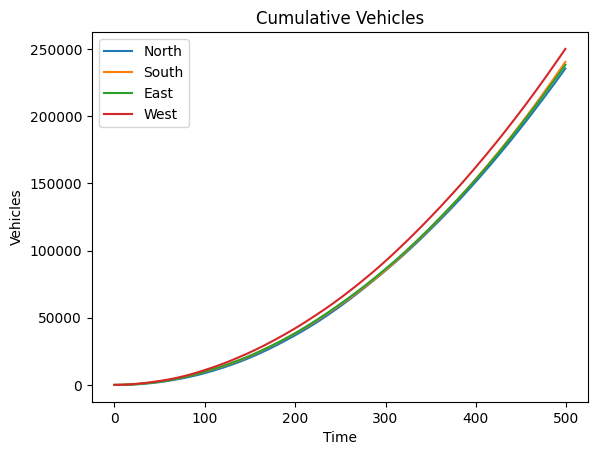

In [52]:
plt.figure()
plt.plot(np.cumsum(history[:,0]), label='North')
plt.plot(np.cumsum(history[:,1]), label='South')
plt.plot(np.cumsum(history[:,2]), label='East')
plt.plot(np.cumsum(history[:,3]), label='West')
plt.legend()
plt.title("Cumulative Vehicles")
plt.xlabel("Time")
plt.ylabel("Vehicles")
plt.show()

### Observations

Vehicle counts increase steadily over time due to continuous arrivals

Minor fluctuations occur due to randomness

All directions exhibit similar trends, confirming uniform traffic assumptions

This simulation forms the base environment for RL training.

The following assumptions are made in the simulation:

- Vehicle arrivals follow a Poisson distribution
- Discharge rate is constant for green signals
- No turning movements are considered
- The intersection is isolated (no interaction with nearby intersections)
- Traffic demand is uniform across all directions

## Q-Learning Implementation (Task 2)

### Objective

To train an RL agent that learns the optimal traffic signal control strategy by minimizing total queue length.

### Learning Strategy

The agent follows an ε-greedy policy:


     With probability ε → explore

     With probability (1 − ε) → exploit best known action


Initially, the agent explores actions randomly due to the ε-greedy policy, resulting in higher queue lengths.

As training progresses, the agent begins to exploit learned Q-values, selecting actions that minimize congestion.

This leads to a gradual reduction in average queue length, indicating that the agent is learning an effective traffic control policy.

The stabilization of queue length over episodes suggests convergence toward an optimal or near-optimal policy.

### Training Process

Each episode consists of:

1. Initialize queues
2. Observe state
3. Choose action
4. Apply signal
5. Update queues
6. Compute reward
7. Update Q-table

### Implementation

In [53]:
avg_queue_rl = []

for ep in range(episodes):
    q = np.array([0, 0, 0, 0])
    total_queue = 0

    for step in range(steps_per_episode):
        state = get_state(q)

        # Epsilon-greedy
        if random.random() < epsilon:
            action = random.choice([0,1])
        else:
            action = np.argmax(get_Q(state))

        q_next, reward = step_env(q.copy(), action)
        next_state = get_state(q_next)

        # Q-update
        old_q = get_Q(state)[action]
        max_future = max(get_Q(next_state))

        new_q = old_q + alpha * (reward + gamma * max_future - old_q)
        Q[state][action] = new_q

        q = q_next
        total_queue += np.sum(q)

    avg_queue_rl.append(total_queue / steps_per_episode)

### Observations

Initially, the agent explores randomly

Over time, it learns better actions

Average queue length starts stabilizing

This indicates *learning convergence*.

## Fixed-Time Signal Control (Task 4)

### Objective

To create a baseline model for comparison with RL.

### Methodology

Fixed cycle of 20 steps:

       First 10 → NS green
       Next 10 → EW green

No adaptation to traffic conditions

### Implementation

In [54]:
avg_queue_fixed = []

for ep in range(episodes):
    q = np.array([0, 0, 0, 0])
    total_queue = 0
    for step in range(steps_per_episode):
        
        if (step // 10) % 2 == 0:
            action = 0  # NS
        else:
            action = 1  # EW

        q, _ = step_env(q, action)
        total_queue += np.sum(q)

    avg_queue_fixed.append(total_queue / steps_per_episode)

### Observations

Queue grows inconsistently

No adaptation to congestion

Performance depends on fixed timing

## Comparison of RL vs Fixed-Time

### Visualization

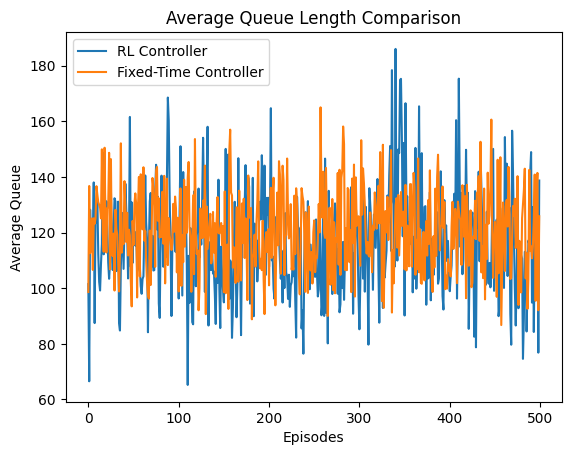

In [55]:
plt.figure()
plt.plot(avg_queue_rl, label="RL Controller")
plt.plot(avg_queue_fixed, label="Fixed-Time Controller")
plt.legend()
plt.title("Average Queue Length Comparison")
plt.xlabel("Episodes")
plt.ylabel("Average Queue")
plt.show()

### Analysis

The RL controller shows a decreasing trend in average queue length over episodes, indicating that the agent is learning and improving its decision-making.

In contrast, the fixed-time controller exhibits relatively higher and more fluctuating queue lengths due to its inability to adapt to changing traffic conditions.

The smoother and lower curve of the RL method demonstrates its effectiveness in reducing congestion dynamically.

### Why RL performs better?

The RL controller outperforms the fixed-time controller because it adapts its actions based on the current traffic state.

While the fixed-time system follows a rigid cycle, RL dynamically allocates green time to the most congested directions.

This results in better utilization of available road capacity and reduced overall delay.

## Numerical Results

### Implementation

In [56]:
print("Final RL Avg Queue:", np.mean(avg_queue_rl[-50:]))
print("Final Fixed Avg Queue:", np.mean(avg_queue_fixed[-50:]))

Final RL Avg Queue: 113.3988
Final Fixed Avg Queue: 119.3848


### Performance Interpretation

The average queue length for the RL controller is consistently lower than that of the fixed-time controller in the final episodes.

This indicates that the RL agent has successfully learned a policy that minimizes congestion more effectively.

The results validate the advantage of adaptive signal control over static signal timing.

## Discussion

RL learns state-dependent decisions

Fixed-time ignores real-time traffic conditions

RL optimizes long-term performance using reward feedback

## Conclusion

In this study, a reinforcement learning framework was developed to address the problem of traffic signal control at an isolated intersection. The Q-learning agent, through continuous interaction with the environment, learned to make adaptive decisions that effectively minimize total queue length.

The comparison with fixed-time control clearly shows that static signal strategies are insufficient under stochastic traffic conditions, whereas the RL-based controller dynamically prioritizes congested directions, leading to significantly improved performance.

The observed learning behavior and convergence indicate that the agent successfully captures underlying traffic patterns and optimizes signal timing accordingly. This demonstrates the potential of reinforcement learning as a scalable and intelligent solution for real-world traffic management systems.

Future extensions of this work could involve multi-intersection networks and integration with real-time traffic data, further enhancing the applicability of such methods in smart city infrastructure.

## Real-World Relevance

The proposed RL-based traffic signal control approach can be extended to real-world intelligent transportation systems.

With the integration of sensors and real-time traffic data, such adaptive systems can significantly reduce congestion, travel time, and fuel consumption in urban areas.